# 📘 Assignment: Linear Regression

## 📌 Objective

The goal of this assignment is to help you **understand and remember the complete Machine Learning (ML) pipeline** by applying it step-by-step to a **Linear Regression** problem.

By the end of this assignment, you should be able to:

- Clearly explain each stage of the ML pipeline
- Train and evaluate linear regression models
- Interpret model coefficients and intercepts
- Compare single-feature vs multi-feature regression models

---




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 🧠 The Machine Learning Pipeline

For **both tasks**, you must explicitly follow and document **all** of the following steps:

1. **Data Retrieval and Collection**
2. **Data Cleaning**
3. **Feature Design**
4. **Algorithm Selection**
5. **Loss Function Selection**
6. **Model Learning (Training)**
7. **Model Evaluation**

⚠️ *Skipping or merging steps will result in loss of marks.*

---

## 📊 Dataset

You will use the **California Housing Dataset**, which contains information about housing districts in California.

### Target Variable (Label)
- `median_house_value`

### Input Features (Examples)
- `housing_median_age`
- `total_rooms`
- `total_bedrooms`
- `population`
- `households`
- `median_income`
- etc.

---

# 🧪 Task 1: Simple Linear Regression (Single Feature)

### 🎯 Problem Statement

Build a **simple linear regression model** using **only one input feature** to predict housing prices.

- **Input Feature:** `housing_median_age`
- **Label:** `median_house_value`

---

### 🔍 Step-by-Step Requirements

## 1️⃣ Data Retrieval and Collection
- Load the California Housing dataset
- Display basic information (shape, column names)

In [2]:
df = pd.read_csv("housing.csv")
list(df.columns)

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.shape

(20640, 10)

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Explanation

The California Housing dataset contains information about housing districts in California, such as population, income, number of rooms, house age, etc. The objective is to predict the median house value.

The dataset is loaded using Pandas, after which its shape, column names, and summary statistics are examined. This initial exploration helps us understand the available features and identify any potential data quality issues before model building.

## 2️⃣ Data Cleaning
- Handle missing values (if any)
- Explain how missing values were treated
- Verify data types

In [6]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df = df.dropna(axis=0)  # remove the rows having missing values

In [8]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

### Explanation

Before training a machine learning model, the dataset must be cleaned to ensure reliable predictions.

The dataset was checked for missing values using `isna().sum()`. Rows containing missing values were removed using `dropna()` because they represent only a small portion of the dataset and removing them simplifies preprocessing.

The data types of all columns were also verified to ensure numerical features can be used for regression. The categorical feature `ocean_proximity` is not required for Task 1 because only a single numerical feature is used.

## 3️⃣ Feature Design
- Select `housing_median_age` as the only input feature
- Explain why this feature was chosen
- Separate features (`X`) and label (`y`)

In [9]:
features = ["housing_median_age"]

In [10]:
X = df[features]
y = df["median_house_value"] / 10000 # Scaling so that feature and labels are in same scale

### Explanation

For this task, only the feature **housing_median_age** is selected as the predictor variable, while **median_house_value** is used as the target variable.

This feature was chosen because the assignment requires building a simple linear regression model using only one input variable. It also allows us to observe whether the age of houses has a linear relationship with their market value.

## 4️⃣ Algorithm Selection
- Choose **Linear Regression**
- Explain why linear regression is appropriate for this task

In [11]:
model_s = LinearRegression()

### Explanation

Linear Regression was selected because the target variable is continuous and the objective is to predict numerical house prices.

Simple Linear Regression models the relationship between one independent variable and one dependent variable using a straight-line equation:

\[
y = mx + c
\]

where:

- \(m\) is the slope (coefficient)
- \(c\) is the intercept

The algorithm is simple, interpretable, and serves as an excellent baseline model.

## 5️⃣ Loss Function Selection
- Use **Mean Squared Error (MSE)**
- Briefly explain what MSE measures

In [12]:
# By default the loss function is MSE

### Explanation

Mean Squared Error (MSE) is used as the loss function.

MSE measures the average squared difference between the actual house prices and the predicted house prices.

$$
MSE = \frac{1}{n}\sum (y_i-\hat y_i)^2
$$

A smaller MSE indicates that the model's predictions are closer to the actual values. Because the errors are squared, larger prediction errors are penalized more heavily.

## 6️⃣ Model Learning (Training)
- Split the data into training and testing sets
- Train the linear regression model
- Clearly state the learning process

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
model_s.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.1]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['housing_median_age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,17.94
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


### Explanation

The dataset is divided into training and testing sets so that the model can be evaluated on unseen data.

The Linear Regression model learns the coefficient and intercept that minimize the Mean Squared Error on the training dataset using the Ordinary Least Squares (OLS) method.

After training, the learned parameters are used to predict house prices for the test dataset.

## 7️⃣ Model Evaluation
- Evaluate the model on test data
- Report:
  - Mean Squared Error (MSE)
  - (Optional) R² Score
- Provide a short interpretation of the results

In [15]:
y_pred_s = model_s.predict(X_test)
mse_s = mean_squared_error(y_test, y_pred_s)
r2_s = r2_score(y_test, y_pred_s)

print(f"""Single Feature Model Evaluation Results:\n
        MSE : {mse_s:.3f}\n
        R2  :  {r2_s:.3f}""")

Single Feature Model Evaluation Results:

        MSE : 134.952

        R2  :  0.013


### Interpretation

The Simple Linear Regression model achieved a Mean Squared Error (MSE) of **134.952** and an R² score of **0.013** on the test dataset.

The MSE indicates the average squared difference between the predicted and actual house prices. Since errors are squared, larger prediction errors contribute more heavily to the MSE. A lower MSE indicates better predictive performance.

The R² score of **0.013** means that approximately **1.3%** of the variation in median house values is explained by the feature **housing_median_age** alone. This relatively low value suggests that housing age by itself is not a strong predictor of house prices.

Overall, the model captures only a limited relationship between house age and house value. This is expected because housing prices are influenced by many other factors such as median income, location, number of rooms, and population, which are not included in this simple regression model.

## Extra
- Visualize the regression line for Task 1
- Plot predicted vs actual values
- Discuss assumptions of linear regression
---

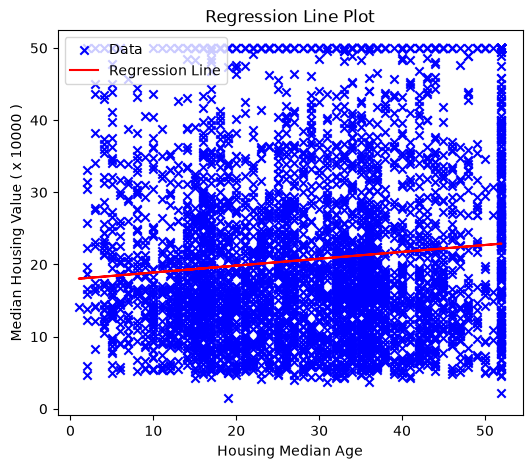

In [16]:
plt.figure(figsize=(6,5))

plt.scatter(X_test, y_test, marker="x", color="blue", label="Data")
plt.plot(X_test, y_pred_s, label="Regression Line", color="red")

plt.xlabel("Housing Median Age")
plt.ylabel("Median Housing Value ( x 10000 )")
plt.title("Regression Line Plot")
plt.legend()
plt.show()

### Regression Line

The regression line represents the best-fitting linear relationship between **housing_median_age** and **median_house_value**.

The line has a positive slope, which indicates that areas with older houses tend to have higher predicted house prices.

The scatter of data points around the regression line shows that there is considerable variability in house prices that cannot be explained by housing age alone. This suggests that additional features are needed to improve prediction accuracy.

### Predicted vs Actual

The Predicted vs Actual plot compares the model's predicted house values with the true house values.

If the predictions were perfect, all points would lie exactly on the diagonal line. However, the points are spread away from the diagonal, indicating prediction errors.

The wide spread of points suggests that the simple linear regression model cannot accurately predict house prices using only **housing_median_age**. This reinforces the conclusion that additional features are necessary to better capture the factors affecting house values.

### Assumptions of Linear Regression

Linear Regression assumes:

- A linear relationship exists between the features and the target.
- Observations are independent.
- Errors have constant variance (homoscedasticity).
- Residuals are approximately normally distributed.
- Features are not highly correlated with each other (important for multiple regression).

## 📈 Model Interpretation (Mandatory)

After training the model, report:

- **Coefficient (slope)**
- **Intercept**

Explain:
- What does the coefficient represent?
- What does the intercept mean in this context?

---

In [17]:
print(f"Model Paramters \nCoefficient : {model_s.coef_}\n Intercept : {model_s.intercept_}")

Model Paramters 
Coefficient : [0.09517606]
 Intercept : 17.94097588097378


## Model Interpretation

After training the Simple Linear Regression model, the learned model parameters are:

- **Coefficient (Slope):** 0.09517606
- **Intercept:** 17.94097588097378

### Coefficient (Slope)

The coefficient of **0.09517606** indicates that for every one-year increase in **housing_median_age**, the predicted **median house value increases by approximately 0.0952 units**.

Since the target variable (**median_house_value**) was divided by **10,000** before training, one unit corresponds to **$10,000**. Therefore,

- **0.0952 × 10,000 ≈ $952**

This means that, according to the model, **each additional year in the median age of houses is associated with an increase of approximately \$952 in the predicted median house value**, assuming all other factors remain constant.

The positive coefficient indicates a positive linear relationship between **housing_median_age** and **median_house_value**.

### Intercept

The intercept is **17.94097588097378**, which means that when the **housing_median_age** is **0 years**, the model predicts a house value of **17.94 units**.

Since the target was scaled by **10,000**, this corresponds to:

**17.94 × 10,000 ≈ \$179,410**

Although a housing median age of zero is not practically meaningful for most districts, the intercept defines where the regression line crosses the y-axis and is necessary for the regression equation.

### Overall Interpretation

The learned regression equation is:

$$
\hat{y} = 0.09517606 \times (\text{housing\_median\_age}) + 17.94097588
$$

where $\hat{y}$ represents the **predicted median house value divided by 10,000**.

The model suggests that there is a positive relationship between housing age and house value. However, the relatively small slope indicates that **housing median age alone has only a modest effect on house prices**. Since house prices depend on many other factors such as median income, number of rooms, population, and location, using only one feature limits the model's predictive performance.

# 🧪 Task 2: Multiple Linear Regression (All Features)

### 🎯 Problem Statement

Build a **multiple linear regression model** using **all available input features** (except the label) to predict housing prices.

- **Input Features:** All remaining features
- **Label:** `median_house_value`

---

### 🔍 Step-by-Step Requirements

Repeat **all seven ML pipeline steps** as in Task 1, but with the following differences:

---

# 1️⃣ Data Retrieval and Collection
- Load the California Housing dataset
- Display basic information (shape, column names)

In [18]:
df = pd.read_csv("housing.csv")
print(df.shape, end="\n\n\n")
display(list(df.columns))
print("\n\n")
display(df.head())
df.describe()

(20640, 10)




['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Explanation

The California Housing dataset contains information about housing districts in California, such as population, income, number of rooms, house age, etc. The objective is to predict the median house value.

The dataset is loaded using Pandas, after which its shape, column names, and summary statistics are examined. This initial exploration helps us understand the available features and identify any potential data quality issues before model building.

## 2️⃣ Data Cleaning
- Handle missing values (if any)
- Explain how missing values were treated
- Verify data types

In [19]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [20]:
df = df.dropna(axis=0)  # remove the rows having missing values

In [21]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

In [22]:
df["ocean_proximity"].unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

### Explanation

Before training a machine learning model, the dataset must be cleaned to ensure reliable predictions.

The dataset was checked for missing values using `isna().sum()`. Rows containing missing values were removed using `dropna()` because they represent only a small portion of the dataset and removing them simplifies preprocessing.

The data types of all columns were also verified to ensure numerical features can be used for regression and the categorical values would be handled using the one hot encoder

## 3️⃣ Feature Design
- Use **all features except** `median_house_value`
- Apply feature scaling if necessary
- Explain why multiple features may improve prediction performance

In [23]:
X = df.drop(["median_house_value"], axis=1)
y = df["median_house_value"] / 10000 # Scaling so that feature and labels are in same scale
# y = df["median_house_value"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
nominal_features = ["ocean_proximity"]
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_train = encoder.fit_transform(X_train[nominal_features])
encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(nominal_features),
    index=X_train.index
)

In [25]:
numerical_features = [col for col in list(X.columns) if col not in nominal_features]
scaler = StandardScaler()


In [26]:
scaled_train = scaler.fit_transform(X_train[numerical_features])
scaled_train_df = pd.DataFrame(
    scaled_train,
    columns=numerical_features,
    index=X_train.index
)

In [27]:
X_train_processed = pd.concat([scaled_train_df, encoded_train_df], axis=1)
X_train_processed.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
17727,-1.106514,0.786208,-1.162062,0.829311,0.929297,1.131110,1.040744,0.438412,1.0,0.0,0.0,0.0,0.0
2057,-0.024671,0.467873,0.348657,-0.738558,-0.850523,-0.708899,-0.856152,-0.242389,0.0,1.0,0.0,0.0,0.0
6453,0.758045,-0.711838,-0.287435,0.587350,0.747242,0.378459,0.691525,-0.108969,0.0,1.0,0.0,0.0,0.0
4619,0.633408,-0.735245,-0.048901,-0.122742,0.989183,1.185124,1.048681,-0.861168,1.0,0.0,0.0,0.0,0.0
15266,1.151895,-1.217429,-0.128412,-0.365632,-0.345083,-0.105008,-0.247664,-0.168986,0.0,0.0,0.0,0.0,1.0


In [28]:
scaled_test = scaler.transform(X_test[numerical_features])
scaled_test_df = pd.DataFrame(
    scaled_test,
    columns=numerical_features,
    index=X_test.index
)
encoded_test = encoder.transform(X_test[nominal_features])
encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(nominal_features),
    index=X_test.index
)

In [29]:
X_test_processed = pd.concat([scaled_test_df, encoded_test_df], axis=1)

### Explanation

In this task, all available input features except the target variable are used. The dataset is divided into training and testing in the ratio of 80:20.

The categorical feature `ocean_proximity` is converted into numerical form using One-Hot Encoding, while numerical features are standardized using feature scaling.

Also all of the encoding and scaling parts are done after train test split and such that the encoder and scaler learn their parameters using only the training data and perform transformations using these parameters to the testing data, preserving data leakage. It is done so using `fit_transform` on training data and `transform` on testing data.

Using multiple features allows the model to capture more information about each housing district, leading to better prediction accuracy compared to using only one feature.

## 4️⃣ Algorithm Selection
- Choose **Linear Regression**
- Explain why linear regression is appropriate for this task

In [30]:
model_m = LinearRegression()

### Explanation

Multiple Linear Regression extends Simple Linear Regression by using several independent variables simultaneously.

The model estimates how each feature contributes to predicting the house value while considering the influence of the other features.

## 5️⃣ Loss Function Selection
- Use **Mean Squared Error (MSE)**
- Briefly explain what MSE measures

In [31]:
# By default the loss function is MSE

### Explanation

Mean Squared Error (MSE) is used as the loss function.

MSE measures the average squared difference between the actual house prices and the predicted house prices.

$$
MSE = \frac{1}{n}\sum (y_i-\hat y_i)^2
$$

A smaller MSE indicates that the model's predictions are closer to the actual values. Because the errors are squared, larger prediction errors are penalized more heavily.

## 6️⃣ Model Learning (Training)
- Split the data into training and testing sets
- Train the linear regression model
- Clearly state the learning process

In [32]:
model_m.fit(X_train_processed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-5.44,-5.48, 1.36,...,17.94,-4.05,-3.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['longitude','latitude','housing_median_age',...,'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,25.35
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


### Explanation

After preprocessing (feature scaling and one-hot encoding), the Linear Regression model learns the coefficients for every input feature using Ordinary Least Squares.

The learned coefficients are then used to predict house prices for unseen test data.

## 7️⃣ Model Evaluation
- Evaluate the model on test data
- Report:
  - Mean Squared Error (MSE)
  - (Optional) R² Score
- Provide a short interpretation of the results

In [33]:
y_pred_m = model_m.predict(X_test_processed)
mse_m = mean_squared_error(y_test, y_pred_m)
r2_m = r2_score(y_test, y_pred_m)

print(f"""Multiple Feature Model Evaluation Results:\n
        MSE : {mse_m:.3f}\n
        R2  :  {r2_m:.3f}""")

Multiple Feature Model Evaluation Results:

        MSE : 48.022

        R2  :  0.649


### Interpretation

The Simple Linear Regression model achieved a Mean Squared Error (MSE) of **48.022
** and an R² score of **0.649** on the test dataset.

The MSE indicates the average squared difference between the predicted and actual house prices. Since errors are squared, larger prediction errors contribute more heavily to the MSE. A lower MSE indicates better predictive performance.

The R² score of **0.649** means that approximately **64.9%** of the variation in median house values is explained by the features.


Compared to the simple linear regression model, this model is achieves a lower MSE and a higher R² score because it utilizes information from all available features.

This indicates that the model captures more of the underlying factors affecting house prices.

### 📈 Model Interpretation (Mandatory)

After training the model, report:

- **Intercept**
- **All coefficients**

Explain:
- What does each coefficient represent?
- How does this model differ from the single-feature model?

---

In [34]:
print(f"Model Paramters \nCoefficients : {model_m.coef_}\n Intercept : {model_m.intercept_}")

Model Paramters 
Coefficients : [-5.43757065 -5.48080362  1.36000883 -1.36131026  4.29998529 -4.11190676
  1.63073412  7.45387382 -3.42694434 -7.35096612 17.93839311 -4.05018603
 -3.11029663]
 Intercept : 25.354493255766954


## Model Interpretation

After training the Simple Linear Regression model, the learned model parameters are:

- **Coefficients (Slopes):** \[-5.43757065 -5.48080362  1.36000883 -1.36131026  4.29998529 -4.11190676
  1.63073412  7.45387382 -3.42694434 -7.35096612 17.93839311 -4.05018603
 -3.11029663 \]
- **Intercept:** 25.354493255766954


### Coefficient (Slope)

Each coefficient represents the expected change in the predicted house value when that feature increases by one unit, while all other features remain constant.

Positive coefficients indicate a direct relationship with house value, while negative coefficients indicate an inverse relationship.

The magnitude of a coefficient reflects the strength of that feature's influence after accounting for the other variables.

### Intercept

The intercept is **25.354493255766954**, which means that every input feature equals zero, the model predicts a house value of **25.35 units**.

Since the target was scaled by **10,000**, this corresponds to:

**25.35 × 10,000 ≈ \$253,544**

Although this situation may not occur in practice, the intercept is necessary for defining the regression equation.

## 📊 Model Comparison

Provide a short comparison between **Task 1 and Task 2**:

- Which model performs better?
- Why does using multiple features help or hurt performance?
- Which model is easier to interpret?

---

In [35]:
comparison = pd.DataFrame({
    "Single Feature (Housing Median Age)": [mse_s, r2_s],
    "Multiple Features (All)": [mse_m, r2_m]
}, index=["MSE", "R2 Score"])

comparison

,Single Feature (Housing Median Age),Multiple Features (All)
MSE,134.952466,48.021735
R2 Score,0.013158,0.648840


### Comparison

**Multiple Linear Regression** has the **MSE** of **48.02** and $R^{2}$ of **0.6488** while the **Simple Linear Regression** has **MSE** of **134.95** and $R^{2}$ of **0.01315**.

The Multiple Linear Regression model performs better than the Simple Linear Regression model because it uses information from all available features instead of relying on only one feature.

Using multiple features generally reduces prediction error and improves the $R^{2}$ score since house prices are influenced by many factors such as income, population, number of rooms, and location.

However, the Simple Linear Regression model is much easier to interpret because it contains only one predictor and one coefficient. The Multiple Linear Regression model is more accurate but also more complex due to the larger number of features.

## 📦 Deliverables

Submit:

- A **Jupyter Notebook (.ipynb)** or **Python script (.py)** containing:
  - Code
  - Clear markdown explanations for each ML pipeline step
- This completed assignment document (optional, if instructed)

---

## 📌 Reminder

> **This assignment is not just about coding — it is about understanding the machine learning process.**

Make sure each step of the pipeline is **clearly explained** in your own words.

Good luck! 🚀